In [2]:

import json
import os
import random
import time

import numpy as np
import torch
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# ----------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ----------------------------------------------------------------------
# Config — edit these directly (works in scripts, Colab, and Jupyter)
# ----------------------------------------------------------------------
EPOCHS = 3          # epochs used at the 100% fraction (smaller fractions get more, see run_transformer)
SEED = 42
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]  # data-efficiency sweep
# For a quick smoke test (much faster), use e.g.:
# FRACTIONS = [0.01, 0.1, 1.0]

MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 4
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
MAX_LENGTH = 128
RESULTS_DIR = "results"


# ----------------------------------------------------------------------
# Data loading
# ----------------------------------------------------------------------
def load_data():
    ds = load_dataset("ag_news")
    return ds["train"], ds["test"]


def subsample(dataset, fraction, seed):
    """Stratified-ish subsample: shuffle then take a fraction. AG News is
    already roughly class-balanced, so a plain shuffle+slice keeps balance
    close enough; we don't over-engineer this."""
    if fraction >= 1.0:
        return dataset
    n = int(len(dataset) * fraction)
    shuffled = dataset.shuffle(seed=seed)
    return shuffled.select(range(n))


# ----------------------------------------------------------------------
# 1. Classical baseline: TF-IDF + Logistic Regression
# ----------------------------------------------------------------------
def run_tfidf_baseline(train_subset, test_ds, seed):
    X_train = train_subset["text"]
    y_train = train_subset["label"]
    X_test = test_ds["text"]
    y_test = test_ds["label"]

    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    clf = LogisticRegression(max_iter=1000, random_state=seed)
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1, "n_train": len(X_train)}


# ----------------------------------------------------------------------
# 2. Transformer fine-tuning
# ----------------------------------------------------------------------
def tokenize_dataset(tokenizer, dataset):
    def _tok(batch):
        return tokenizer(
            batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False
        )
    return dataset.map(_tok, batched=True, remove_columns=["text"])


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }


def run_transformer(train_subset, test_ds, tokenizer, epochs, seed, run_name):
    train_tok = tokenize_dataset(tokenizer, train_subset)
    test_tok = tokenize_dataset(tokenizer, test_ds)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Small subsets get more epochs so the model actually gets a chance to
    # learn from very little data — this is standard practice in few-shot
    # fine-tuning and keeps the comparison fair rather than handicapping
    # the transformer at low data fractions.
    n = len(train_subset)
    effective_epochs = epochs if n > 5000 else min(epochs * 3, 15)

    args = TrainingArguments(
        output_dir=f"./tmp_{run_name}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=effective_epochs,
        weight_decay=0.01,
        logging_steps=50,
        seed=seed,
        report_to=[],
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    elapsed = time.time() - start

    metrics = trainer.evaluate()
    predictions = trainer.predict(test_tok)
    pred_labels = np.argmax(predictions.predictions, axis=-1)

    return {
        "accuracy": metrics["eval_accuracy"],
        "macro_f1": metrics["eval_macro_f1"],
        "n_train": n,
        "epochs": effective_epochs,
        "train_time_sec": elapsed,
    }, trainer, pred_labels, test_tok


# ----------------------------------------------------------------------
# 3. Error analysis + per-class report (on the FULL-data transformer run)
# ----------------------------------------------------------------------
def error_analysis(test_ds, pred_labels, out_path, n_examples=15):
    y_true = np.array(test_ds["label"])
    wrong_idx = np.where(pred_labels != y_true)[0]
    rng = np.random.RandomState(0)
    sample_idx = rng.choice(wrong_idx, size=min(n_examples, len(wrong_idx)), replace=False)

    with open(out_path, "w") as f:
        f.write(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}\n")
        f.write(f"({100 * len(wrong_idx) / len(y_true):.2f}% error rate)\n\n")
        f.write("=" * 70 + "\n")
        for i in sample_idx:
            text = test_ds[int(i)]["text"]
            true_label = LABEL_NAMES[y_true[i]]
            pred_label = LABEL_NAMES[pred_labels[i]]
            f.write(f"TRUE: {true_label:10s} | PRED: {pred_label:10s}\n")
            f.write(f"TEXT: {text}\n")
            f.write("-" * 70 + "\n")


def per_class_report(test_ds, pred_labels, out_path):
    y_true = test_ds["label"]
    report = classification_report(y_true, pred_labels, target_names=LABEL_NAMES)
    with open(out_path, "w") as f:
        f.write(report)
    print(report)


# ----------------------------------------------------------------------
# 4. Plot the data-efficiency curve
# ----------------------------------------------------------------------
def plot_curve(results, out_path):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fractions_pct = [f * 100 for f in FRACTIONS]
    tfidf_acc = [results["tfidf"][str(f)]["accuracy"] for f in FRACTIONS]
    transformer_acc = [results["transformer"][str(f)]["accuracy"] for f in FRACTIONS]

    plt.figure(figsize=(7, 5))
    plt.plot(fractions_pct, transformer_acc, marker="o", label="DistilBERT (fine-tuned)")
    plt.plot(fractions_pct, tfidf_acc, marker="s", label="TF-IDF + Logistic Regression")
    plt.xscale("log")
    plt.xlabel("% of training data used (log scale)")
    plt.ylabel("Test accuracy")
    plt.title("Data-Efficiency: DistilBERT vs. TF-IDF Baseline (AG News)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved plot to {out_path}")


# ----------------------------------------------------------------------
# Main — runs top-to-bottom, no argparse, safe inside Colab/Jupyter
# ----------------------------------------------------------------------
os.makedirs(RESULTS_DIR, exist_ok=True)
set_seed(SEED)

print("Loading AG News...")
train_full, test_ds = load_data()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

results = {"tfidf": {}, "transformer": {}}
last_trainer_pred_labels = None
last_test_tok = None

for frac in FRACTIONS:
    print(f"\n{'=' * 60}\nFRACTION = {frac:.0%}\n{'=' * 60}")
    train_subset = subsample(train_full, frac, seed=SEED)

    # --- TF-IDF baseline at this fraction ---
    print(f"[TF-IDF] training on {len(train_subset)} examples...")
    tfidf_metrics = run_tfidf_baseline(train_subset, test_ds, SEED)
    results["tfidf"][str(frac)] = tfidf_metrics
    print(f"[TF-IDF] acc={tfidf_metrics['accuracy']:.4f} "
          f"macro_f1={tfidf_metrics['macro_f1']:.4f}")

    # --- Transformer at this fraction ---
    print(f"[DistilBERT] training on {len(train_subset)} examples...")
    tf_metrics, trainer, pred_labels, test_tok = run_transformer(
        train_subset, test_ds, tokenizer, EPOCHS, SEED,
        run_name=f"frac_{int(frac * 100)}",
    )
    results["transformer"][str(frac)] = tf_metrics
    print(f"[DistilBERT] acc={tf_metrics['accuracy']:.4f} "
          f"macro_f1={tf_metrics['macro_f1']:.4f}")

    if frac == 1.00:
        last_trainer_pred_labels = pred_labels
        last_test_tok = test_ds  # keep raw text version for error analysis

# Save all numeric results
with open(os.path.join(RESULTS_DIR, "data_efficiency_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved results to {RESULTS_DIR}/data_efficiency_results.json")

# Plot
plot_curve(results, os.path.join(RESULTS_DIR, "data_efficiency_curve.png"))

# Error analysis + per-class report on the full-data transformer model
if last_trainer_pred_labels is not None:
    error_analysis(
        last_test_tok, last_trainer_pred_labels,
        os.path.join(RESULTS_DIR, "error_analysis.txt"),
    )
    per_class_report(
        last_test_tok, last_trainer_pred_labels,
        os.path.join(RESULTS_DIR, "per_class_report_full_model.txt"),
    )

print("\nDone. All results are in the 'results/' directory.")

Loading AG News...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.384963,0.344516,0.940526,0.940591
2,0.237626,0.343847,0.945132,0.945215
3,0.179002,0.379121,0.946316,0.946366


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


[DistilBERT] acc=0.9463 macro_f1=0.9464

Saved results to results/data_efficiency_results.json
Saved plot to results/data_efficiency_curve.png
              precision    recall  f1-score   support

       World       0.96      0.95      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.93      0.91      0.92      1900
    Sci/Tech       0.91      0.94      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600


Done. All results are in the 'results/' directory.


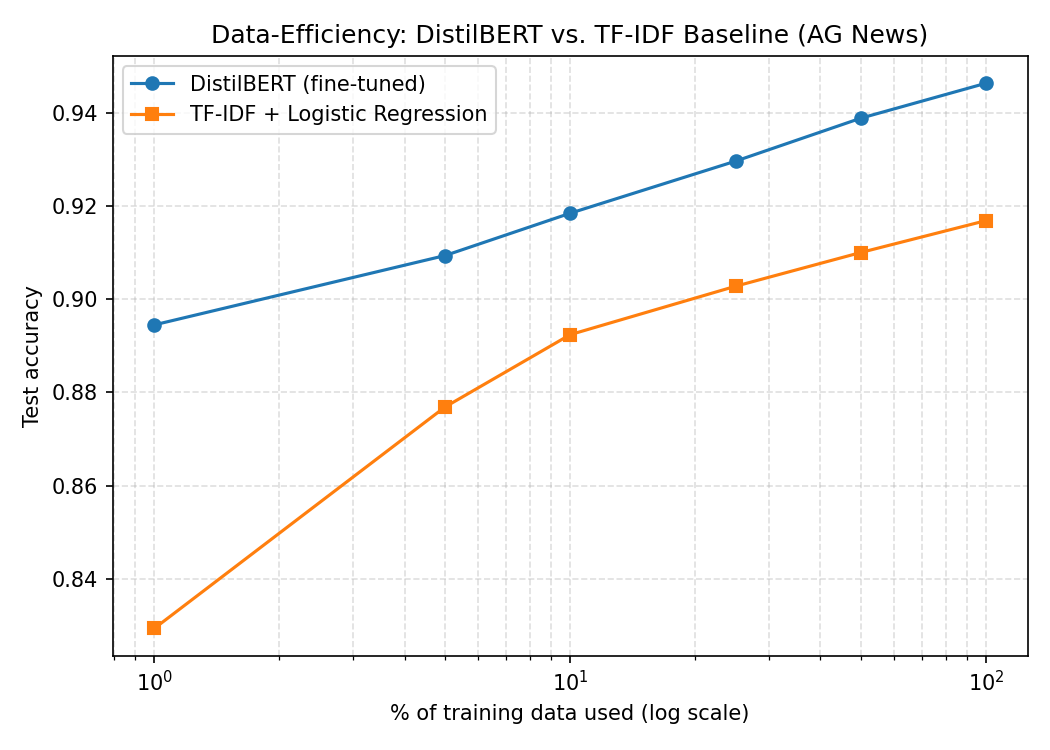

In [3]:
from PIL import Image
img = Image.open("results/data_efficiency_curve.png")
img

In [4]:
import os
for f in os.listdir("results"):
    path = os.path.join("results", f)
    size = os.path.getsize(path)
    print(f"{f:45s} {size:>10,} bytes")

data_efficiency_results.json                       1,836 bytes
data_efficiency_curve.png                         81,220 bytes
per_class_report_full_model.txt                      434 bytes
error_analysis.txt                                 4,870 bytes
